<h1>Generative Adversarial Network</h1>
In this notebook, we will explore a popular method for data generation, the Generative Adversarial Network (GAN). GANs are, in fact, a pair of networks (at least two), a Generator and a Discriminator. The Generator takes a random sample from a distribution (usually a standard normal distribution) and produces an image. The Discriminator takes an image and tries to classify it as either coming from the Generator or the dataset of real images. The twist is that we optimize the Generator to produce an image that the Discriminator classifies as "real" (coming from the dataset). <br>

<img src="../data/MNIST_GAN_DEMO.gif" width="700" align="center">

We do this by generating an image and passing it through the Discriminator and then calculating the loss (as if the fake image were real) and backpropagating the gradients through the Discriminator to the Generator and then updating only the Generator. By doing this, the Generator "sees" how to update itself in such a way that the Discriminator will classify its images as "real". As this is happening at the same time as the Discriminator is learning to distinguish the Generators' "fake" images from the datasets' "real" ones, we get a "bootstrapping" effect. As a result, the Generator gets better at generating "fake" images and the discriminator gets better at detecting fake from real, until (ideally) the fake images are indistinguishable from real.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets
import torchvision.transforms.v2 as transforms
import torchvision.utils as vutils

import os
import matplotlib.pyplot as plt
import numpy as np
import imageio

from tqdm.auto import trange, tqdm

In [2]:
batch_size = 128
dlr = 1e-6
glr = 1e-4

train_epoch = 25

# data_loader
img_size = 32

data_set_root = "../../datasets"

<b> Use a GPU if avaliable </b>

In [3]:
use_cuda = torch.cuda.is_available()
gpu_indx  = 0
device = torch.device(gpu_indx if use_cuda else "CPU")
print(torch.cuda.get_device_name(gpu_indx) if use_cuda else "CPU")

NVIDIA GeForce RTX 4060 Laptop GPU


In [4]:
transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32),
    transforms.Normalize(mean=([0.5]), std=([0.5]))
])

trainset = datasets.MNIST(data_set_root, train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

<h2>Adversarial Training</h2>
<img src="../data/GAN.jpg" width="700" align="center">


<h3> Generator </h3>
Our Generator is a simple transpose convolution network; it takes in a vector as input and upsamples it multiple times until it is the desired size.<br>
NOTE: We use a 3D tensor for the input instead of a 1D vector, as it is easier to just use transpose convolution layers for everything instead of having to reshape the input.

In [5]:
class Generator(nn.Module):
    def __init__(self, z=64, ch=16):
        super(Generator, self).__init__()
        self.conv1 = nn.ConvTranspose2d(z, ch * 8, 4, 1, 0)
        self.bn1 = nn.BatchNorm2d(ch * 8)

        self.conv2 = nn.Conv2d(ch * 8, ch * 4, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(ch * 4)
        
        self.conv3 = nn.Conv2d(ch * 4, ch * 2, 3, 1, 1)
        self.bn3 = nn.BatchNorm2d(ch * 2)
        
        self.conv4 = nn.Conv2d(ch * 2, ch * 2, 3, 1, 1)
        self.bn4 = nn.BatchNorm2d(ch * 2)

        self.conv_out = nn.Conv2d(ch * 2, 1, 3, 1, 1)
        self.up_nn = nn.Upsample(scale_factor=2, mode="nearest")

    # Forward method
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.up_nn(F.relu(self.bn2(self.conv2(x))))
        x = self.up_nn(F.relu(self.bn3(self.conv3(x))))
        x = self.up_nn(F.relu(self.bn4(self.conv4(x))))

        return torch.tanh(self.conv_out(x))

# Discriminator

The Discriminator is a simple convolutional classifier network that has a single output.<br>
NOTE: The output is also a 3D tensor for a single output; we will squish it before calculating the loss

In [ ]:
class Discriminator(nn.Module):
    # initializers
    def __init__(self, ch=16):
        super(Discriminator, self).__init__()
        self.conv_in = nn.Conv2d(1, ch, 4, 2, 1)  # Changed kernel size and stride

        self.conv1 = nn.Conv2d(ch, ch*2, 4, 2, 1)
        self.bn1 = nn.BatchNorm2d(ch*2)
        
        self.conv2 = nn.Conv2d(ch*2, ch*4, 4, 2, 1)
        self.bn2 = nn.BatchNorm2d(ch*4)
        
        self.conv3 = nn.Conv2d(ch*4, ch*8, 4, 2, 1)
        self.bn3 = nn.BatchNorm2d(ch*8)

        self.conv_out = nn.Conv2d(ch*8, 1, 2, 1, 0)  # Final classification layer

        self.dropout = nn.Dropout(0.2)

    # forward method
    def forward(self, x):
        x = F.leaky_relu(self.conv_in(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.bn1(self.conv1(x)), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)
        x = self.dropout(x)
        
        x = self.conv_out(x).reshape(x.shape[0], 1)
        return x

In [7]:
def gan_bce_loss(output, real_label=True):
    if real_label:
        # Use label smoothing: instead of 1.0, use 0.9
        target = torch.full_like(output, 0.9)
    else:
        # Add some noise to fake labels: instead of 0.0, use 0.1
        target = torch.full_like(output, 0.1)
    return F.binary_cross_entropy_with_logits(output, target)

In [8]:
def gan_w_loss(output, real_label=True):
    if real_label:
        return -output.mean()
    else:
        return output.mean()

<h2> Basic GAN Model</h2>

![alt text](https://miro.medium.com/max/1600/1*M_YipQF_oC6owsU1VVrfhg.jpeg)

A more formal way of describing what is going on is to characterise our dataset as a discrete sample from some high-dimensional distribution $d_r$ (where every pixel value is a degree of freedom). Our Generator maps from some input distribution $N(0,1)$ to $d_f$ and the Discriminator tries to learn to distinguish $d_r$ from $d_f$ while the Generator tries to make $d_f = d_r$ at which point the Discriminator cannot tell the difference. 

<h3>Define Hyperparameters, Network and Optimizer</h3>
GANs are very instable and sensitive to hyperparameters, see how well you can get the generated output by tuning hyperparameters.

In [9]:
# network
latent_noise_dem = 128

g_net = Generator(latent_noise_dem, ch=32).to(device)
d_net = Discriminator(ch=32).to(device)

#A fixed latent noise vector so we can see the improvement over the epochs
fixed_latent_noise = torch.randn(16, latent_noise_dem, 1, 1).to(device)

# Adam optimizer with GAN-specific betas
g_optimizer = optim.Adam(g_net.parameters(), lr=glr, betas=(0.5, 0.999))
d_optimizer = optim.Adam(d_net.parameters(), lr=dlr, betas=(0.5, 0.999))

In [10]:
# If you are using gradient clipping, initialise the params to be smaller
# with torch.no_grad():
#     for param in d_net.parameters():
#         param.data *= 0.01

In [11]:
test_images_log = []
d_losses = []
g_losses = []

d_out_fake = []
d_out_real = []

g_loss = 0
d_loss = 0

In [12]:
def plot_training_metrics(d_losses, g_losses, d_out_real, d_out_fake):
    """Plot training metrics to monitor GAN training balance"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot losses
    axes[0, 0].plot(d_losses, label='Discriminator Loss', alpha=0.7)
    axes[0, 0].plot(g_losses, label='Generator Loss', alpha=0.7)
    axes[0, 0].set_title('Training Losses')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Plot discriminator outputs
    axes[0, 1].plot(d_out_real, label='D(real)', alpha=0.7)
    axes[0, 1].plot(d_out_fake, label='D(fake)', alpha=0.7)
    axes[0, 1].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Ideal Balance')
    axes[0, 1].set_title('Discriminator Outputs')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Plot moving averages
    window = 100
    if len(d_losses) > window:
        d_loss_ma = np.convolve(d_losses, np.ones(window)/window, mode='valid')
        g_loss_ma = np.convolve(g_losses, np.ones(window)/window, mode='valid')
        axes[1, 0].plot(d_loss_ma, label='D Loss (MA)')
        axes[1, 0].plot(g_loss_ma, label='G Loss (MA)')
        axes[1, 0].set_title('Moving Average Losses')
        axes[1, 0].legend()
        axes[1, 0].grid(True)
    
    # Plot discriminator accuracy
    if len(d_out_real) > 0 and len(d_out_fake) > 0:
        # Convert logits to probabilities for accuracy calculation
        real_acc = [1 if x > 0 else 0 for x in d_out_real]
        fake_acc = [1 if x < 0 else 0 for x in d_out_fake]
        
        if len(real_acc) > window:
            real_acc_ma = np.convolve(real_acc, np.ones(window)/window, mode='valid')
            fake_acc_ma = np.convolve(fake_acc, np.ones(window)/window, mode='valid')
            axes[1, 1].plot(real_acc_ma, label='Real Accuracy')
            axes[1, 1].plot(fake_acc_ma, label='Fake Accuracy')
            axes[1, 1].axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
            axes[1, 1].set_title('Discriminator Accuracy')
            axes[1, 1].legend()
            axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.show()

# The main training loop


The overall objective function is: ![alt text](https://miro.medium.com/max/1500/1*l9se1koH_eQdZesko5eQpw.jpeg)

This is also formalised as a "minmax" game, where the Generator is trying to minimise the above loss function for a Discriminator that is trying to maximise itabove

The Loss function we are using is the binary cross-entropy loss because what the Discriminator does is essentially a binary classification problem: Real or Fake. At the point where $d_f = d_r$, the output of our Discriminator should be 0.5 (halfway between 0 and 1 - note this rarely actually happens)<br>


GANs can be difficult to train. Some common reasons are:
1. At the beginning, the distribution of real and fake samples is far away from each other, making it easy for the Discriminator to tell the fake from the real

3. The Discriminator becomes too good and stops providing useful gradients back to the Generator

2. The Discriminator becomes bad and cannot tell the difference between the real and fake samples, even though the output from the generator is bad

3. The Generator overpowers the Discriminator and the Discriminator cannot tell real from fake (even though $d_f \neq d_r$)

4. The Generator starts outputting only a very few images (low variation in the images), and as the Discriminator is only looking for fake images, it is not corrected

In [13]:
pbar = trange(train_epoch, leave=False, desc="Epoch")    
for epoch in pbar:
    pbar.set_postfix_str('G Loss: %.4f, D Loss: %.4f' % (g_loss/len(train_loader), 
                                                         d_loss/len(train_loader)))
    g_loss = 0
    d_loss = 0

    for num_iter, (images, label) in enumerate(tqdm(train_loader, leave=False)):
        images = images.to(device)
        
        bs = images.shape[0]

        ########### Train Generator ##############
        latent_noise = torch.randn(bs, latent_noise_dem, 1, 1).to(device)
        g_output = g_net(latent_noise)
        
        d_result = d_net(g_output)
        g_train_loss = gan_bce_loss(d_result, True)
        
        g_net.zero_grad()
        g_train_loss.backward()
        g_optimizer.step()
        
        g_losses.append(g_train_loss.item())
        g_loss += g_train_loss.item()

        ########### Train Discriminator ############
        d_real_out = d_net(images)
        d_real_loss = gan_bce_loss(d_real_out, True)
        d_out_real.append(d_real_out.mean().item())
        
        d_fake_out = d_net(g_output.detach())
        d_fake_loss = gan_bce_loss(d_fake_out, False)
        d_out_fake.append(d_fake_out.mean().item())

        d_train_loss = (d_real_loss + d_fake_loss)/2

        d_net.zero_grad()
        d_train_loss.backward()
        d_optimizer.step()
                
        d_losses.append(d_train_loss.item())
        d_loss += d_train_loss.item()

        with torch.no_grad():
            g_net.eval()
            #log the output of the generator given the fixed latent noise vector
            test_fake = g_net(fixed_latent_noise)
            imgs = torchvision.utils.make_grid(test_fake.cpu().detach(), 4, pad_value=1, normalize=True)
            imgs_np = (imgs.numpy().transpose((1, 2, 0)) * 255).astype(np.uint8)
            test_images_log.append(imgs_np)
            g_net.train()

Epoch:   0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/469 [00:00<?, ?it/s]

...

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/469 [00:00<?, ?it/s]

<h3>Plot out the losses and visualize the generated images</h3>
Notice how noisy the losses for both the Generator and Discriminator are?

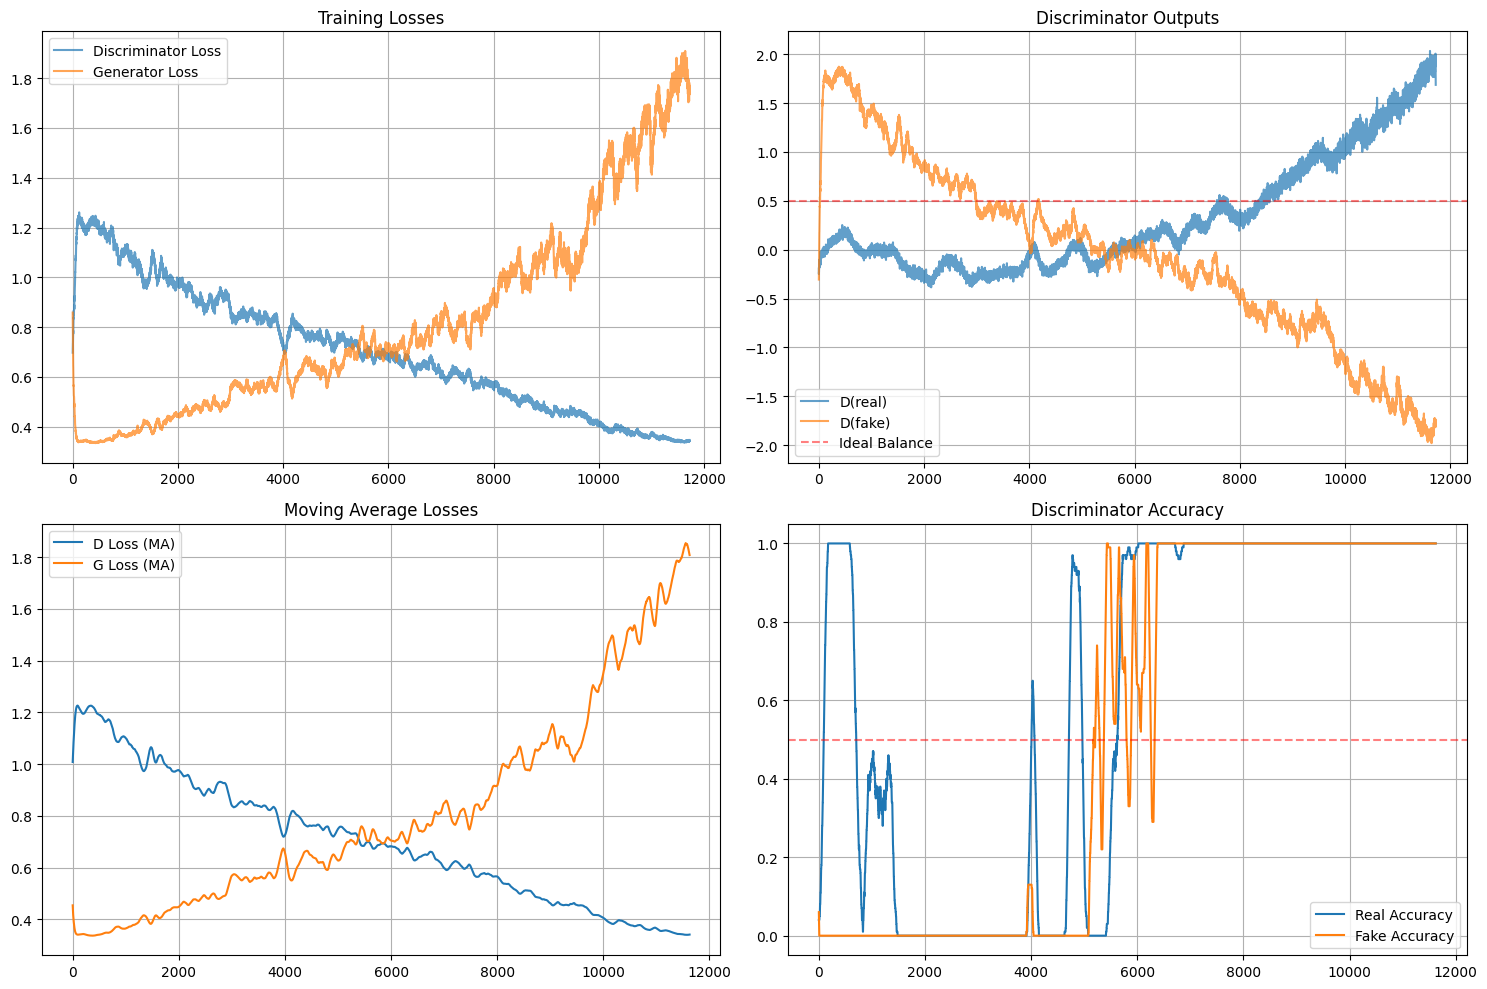

In [14]:
# Plot comprehensive training metrics
plot_training_metrics(d_losses, g_losses, d_out_real, d_out_fake)

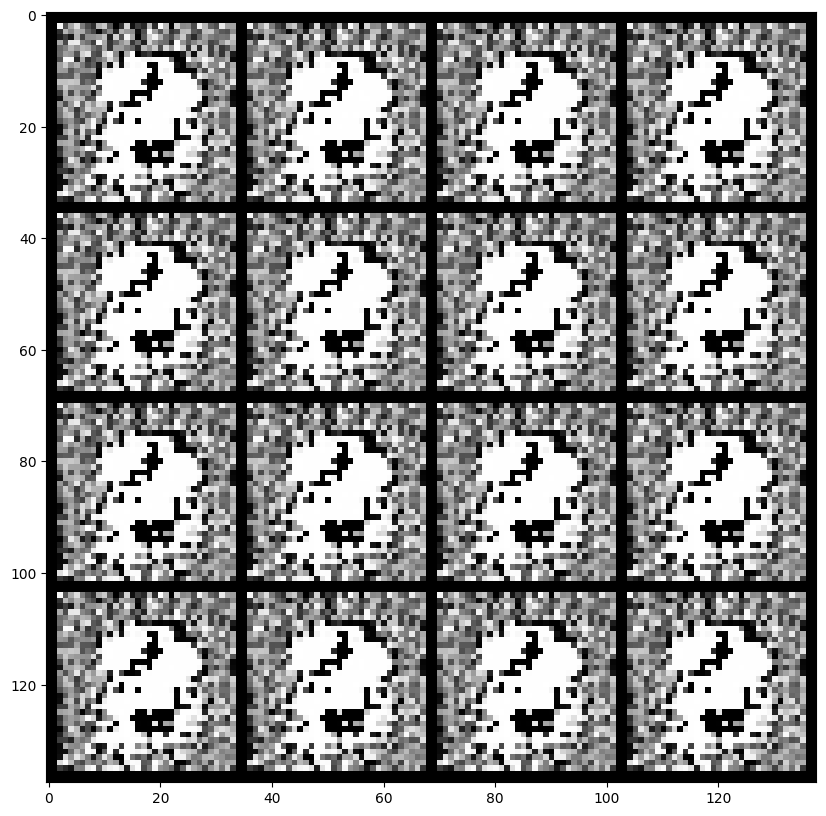

In [15]:
test_fake = g_net(fixed_latent_noise)
plt.figure(figsize = (20,10))
out = vutils.make_grid(test_fake.detach().cpu(), 4, normalize=True)
plt.imshow(out.numpy().transpose((1, 2, 0)))

<b>Lets create a gif of our generated images throughout training</b>

In [16]:
imageio.mimsave('MNIST_GAN.gif', test_images_log)